In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import StratifiedKFold, GridSearchCV, learning_curve, cross_val_predict
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             average_precision_score, precision_recall_curve, 
                             roc_curve, PrecisionRecallDisplay)

import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append(r"D:\baitaplon\hr-churn-predictor\hr-churn-predictor\backend")
from custom_transformers.randomforest_transformers import RF_MissingValueHandler, RF_OrdinalMapper, RF_FrequencyEncoder

In [7]:
file_id = '1e8ImAsI7nDfDyyDCRo6cy2Bde1WEa_mY' # ID file dataset
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df_raw = pd.read_csv(url)
df = df_raw.drop(columns=['enrollee_id'])

# Tách feature matrix X và vector nhãn y
X = df.drop(columns=['target'])
y = df['target'].astype(int)  # Chuyển sang int (0/1)]

# 3. Chia dữ liệu thành tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # Đảm bảo tỷ lệ nhãn ở tập train/test giống nhau
)

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước y_train: {y_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước y_test: {y_test.shape}")

Kích thước X_train: (15326, 12)
Kích thước y_train: (15326,)
Kích thước X_test: (3832, 12)
Kích thước y_test: (3832,)


In [8]:
# # --- ĐỊNH NGHĨA CÁC LỚP TIỀN XỬ LÝ  ---
# class RF_MissingValueHandler(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         #Khai báo MODE_COLS và MEDIAN_COLS 
#         self.MODE_COLS = ['relevent_experience', 'enrolled_university', 'education_level', 'experience', 'last_new_job']
#         self.MEDIAN_COLS = ['city_development_index', 'training_hours']   
#         self.mode_values = {}
#         self.median_values = {}
#     def fit(self, X, y=None):
#         # Học giá trị Mode
#         for col in self.MODE_COLS:
#             self.mode_values[col] = X[col].mode()[0]   
#         # Học giá trị Median
#         for col in self.MEDIAN_COLS:
#             self.median_values[col] = X[col].median()   
#         return self
#     def transform(self, X):
#         X_copy = X.copy()
#         X_copy[['company_size', 'company_type', 'gender']] = X_copy[['company_size', 'company_type', 'gender']].fillna('Unknown')
#         X_copy['major_discipline'] = X_copy['major_discipline'].fillna('No Info')
#         for col in self.MODE_COLS:
#             X_copy[col] = X_copy[col].fillna(self.mode_values[col])  
#         for col in self.MEDIAN_COLS:
#             X_copy[col] = X_copy[col].fillna(self.median_values[col])
            
#         return X_copy

In [9]:
# class RF_OrdinalMapper(BaseEstimator, TransformerMixin):
#     def fit(self, X, y=None):
#         return self
#     def transform(self, X):
#         X_copy = X.copy()
#         edu_map = {'Primary School': 0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd': 4}
#         X_copy['education_level'] = X_copy['education_level'].map(edu_map)
#         exp_map = {'<1': 0, '>20': 21}
#         for i in range(1, 21): exp_map[str(i)] = i
#         X_copy['experience'] = X_copy['experience'].map(exp_map)
#         size_map = {'Unknown': -1, '<10': 0, '10/49': 1, '50-99': 2, '100-500': 3, '500-999': 4, '1000-4999': 5, '5000-9999': 6, '10000+': 7}
#         X_copy['company_size'] = X_copy['company_size'].map(size_map)
#         job_map = {'never': 0, '1': 1, '2': 2, '3': 3, '4': 4, '>4': 5}
#         X_copy['last_new_job'] = X_copy['last_new_job'].map(job_map)
#         return X_copy
# class RF_FrequencyEncoder(BaseEstimator, TransformerMixin):
#     def __init__(self, column='city'):
#         self.column = column
#         self.freq_map = {} 
#     def fit(self, X, y=None):
#         return self
#     def transform(self, X):
#         X_copy = X.copy()
#         X_copy[self.column] = X_copy[self.column].map(self.freq_map).fillna(0)
#         return X_copy

In [10]:
# Load mô hình
def load_system_model(
    model_path='randomforest_output/best_randomforest_model.joblib', 
    threshold_path='randomforest_output/best_threshold.txt'
):
    pipeline = joblib.load(model_path)
    with open(threshold_path, 'r') as f:
        threshold = float(f.read())
    return pipeline, threshold
    pipeline_loaded, optimal_threshold = load_system_model()
print("Đã tải mô hình và threshold thành công!")
# Hàm dự doán dữ liệu mới
def predict_new_candidates(raw_data):
    if isinstance(raw_data, dict):
        df_new = pd.DataFrame([raw_data])
    else:
        df_new = pd.DataFrame(raw_data)
        
    probabilities = pipeline_loaded.predict_proba(df_new)[:, 1]
    predictions = (probabilities >= optimal_threshold).astype(int)
    labels_map = {0: 'Không tìm việc', 1: 'Đang tìm việc'}
    
    results = []
    for prob, pred in zip(probabilities, predictions):
        results.append({
            'probability': float(prob),
            'prediction_label': int(pred),
            'prediction_text': labels_map[pred]
        })
    return results
def predict_new_candidates(raw_data):
    """
    raw_data: Dictionary hoặc DataFrame chứa dữ liệu thô của ứng viên mới.
              Ví dụ: {'city': 'city_103', 'city_development_index': 0.92, ...}
    """
    # Chuyển đổi dữ liệu đầu vào thành DataFrame nếu là dữ liệu đơn lẻ dạng dict
    if isinstance(raw_data, dict):
        df_new = pd.DataFrame([raw_data])
    else:
        df_new = pd.DataFrame(raw_data)
    # Pipeline tự động chạy qua MissingValueHandler, OrdinalMapper, 
    # FrequencyEncoder, ColumnTransformer rồi mới đưa vào Random Forest dự đoán xác suất.
    probabilities = pipeline_loaded.predict_proba(df_new)[:, 1]
    # Áp dụng chính xác ngưỡng threshold tối ưu để phân nhãn
    predictions = (probabilities >= optimal_threshold).astype(int)
    # Ánh xạ nhãn số sang trạng thái thực tế
    labels_map = {0: 'Không tìm việc', 1: 'Đang tìm việc'}
    results = []
    for prob, pred in zip(probabilities, predictions):
        results.append({
            'probability': float(prob),
            'prediction_label': int(pred),
            'prediction_text': labels_map[pred]
        })
        
    return results

Đã tải mô hình và threshold thành công!


In [11]:
# Các cột cho ColumnTransformer
OHE_COLS_RF = ['gender', 'relevent_experience', 'enrolled_university', 'major_discipline', 'company_type', 'company_size']
FREQ_COL = 'city'

col_transformer_rf = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), OHE_COLS_RF),
        ('scaler_std', StandardScaler(), ['city_development_index', FREQ_COL]),
        ('log1p_std', Pipeline([
            ('log', FunctionTransformer(np.log1p, validate=True)),
            ('scale', StandardScaler()),
        ]), ['training_hours']),
    ],
    remainder='passthrough',
    verbose_feature_names_out=True
)

In [12]:
# Khai báo mô hình + Pipeline + ParamGrid
full_pipeline_rf = Pipeline(steps=[
    ('missing_handler', RF_MissingValueHandler()),
    ('ordinal_mapper', RF_OrdinalMapper()),
    ('freq_encoder', RF_FrequencyEncoder(column=FREQ_COL)),
    ('col_transformer', col_transformer_rf),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],         # Số lượng cây
    'model__max_depth': [10, 15, None],        # Độ sâu tối đa (tránh overfit)
    'model__min_samples_split': [2, 5]         # Số mẫu tối thiểu để tách node
}

In [13]:
# Huấn luyện bằng CV + GridSearchCV
print("\n--- Chạy GridSearchCV tìm siêu tham số ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=full_pipeline_rf,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1, # Chạy đa luồng trên local
    verbose=1
)

grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_

print(f"Tham số tốt nhất: {grid_search.best_params_}")
print(f"ROC-AUC CV tốt nhất: {grid_search.best_score_:.4f}")


--- Chạy GridSearchCV tìm siêu tham số ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Tham số tốt nhất: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
ROC-AUC CV tốt nhất: 0.7964



--- Learning Curve ---


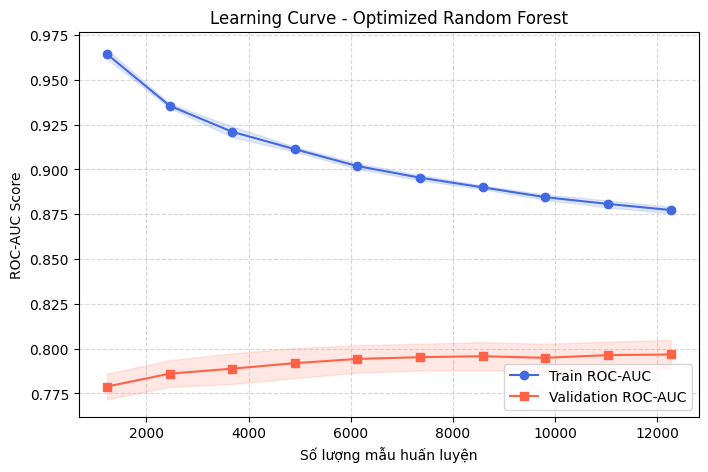

In [14]:
# Vẽ Learning Curve trên best_estimator
print("\n--- Learning Curve ---")
train_sizes, train_scores, val_scores = learning_curve(
    best_rf_model, X_train, y_train, 
    cv=cv, scoring='roc_auc', 
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, random_state=42
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Train ROC-AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
plt.plot(train_sizes, val_mean, 's-', color='tomato', label='Validation ROC-AUC')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')
plt.title('Learning Curve - Optimized Random Forest')
plt.xlabel('Số lượng mẫu huấn luyện')
plt.ylabel('ROC-AUC Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [15]:
# Tìm Threshold tối ưu trên TẬP TRAIN (cross_val_predict)
print("\n--- BƯỚC 4: Tìm Threshold tối ưu trên Tập Train ---")
y_train_cv_proba = cross_val_predict(best_rf_model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_cv_proba)
# F1-score chỉ xác định với các ngưỡng tương ứng
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Ngưỡng (Threshold) tối ưu tìm được: {optimal_threshold:.4f}")


--- BƯỚC 4: Tìm Threshold tối ưu trên Tập Train ---
Ngưỡng (Threshold) tối ưu tìm được: 0.5551



--- Đánh giá mô hình trên Tập Test ---
ROC-AUC Test: 0.8124
PR-AUC Test:  0.5495
F2-Score: 0.7151

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      2877
           1       0.54      0.78      0.64       955

    accuracy                           0.78      3832
   macro avg       0.73      0.78      0.74      3832
weighted avg       0.82      0.78      0.79      3832



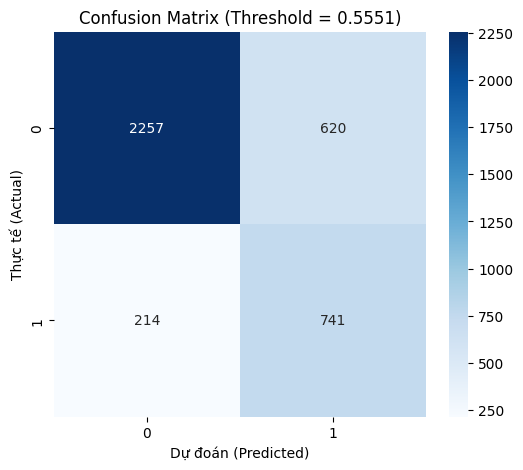

In [26]:
# Đừng quên import thêm thư viện nếu chưa có:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict trên Tập Test & In báo cáo
print("\n--- Đánh giá mô hình trên Tập Test ---")
y_test_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Áp dụng threshold tìm được ở Bước 4
y_test_pred_opt = (y_test_proba >= optimal_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

# Tính trực tiếp F2-Score cho nhãn 1 qua công thức
p_1 = precision_score(y_test, y_test_pred_opt, zero_division=0)
r_1 = recall_score(y_test, y_test_pred_opt, zero_division=0)

# Áp dụng công thức: F2 = 5 * (P * R) / (4*P + R). Tránh lỗi chia cho 0 nếu cả P và R đều bằng 0
f2_score_1 = (5 * p_1 * r_1) / (4 * p_1 + r_1) if (4 * p_1 + r_1) > 0 else 0.0

print(f"ROC-AUC Test: {roc_auc:.4f}")
print(f"PR-AUC Test:  {pr_auc:.4f}")
print(f"F2-Score: {f2_score_1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_test_pred_opt))

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()


--- Biểu đồ ROC và PR ---


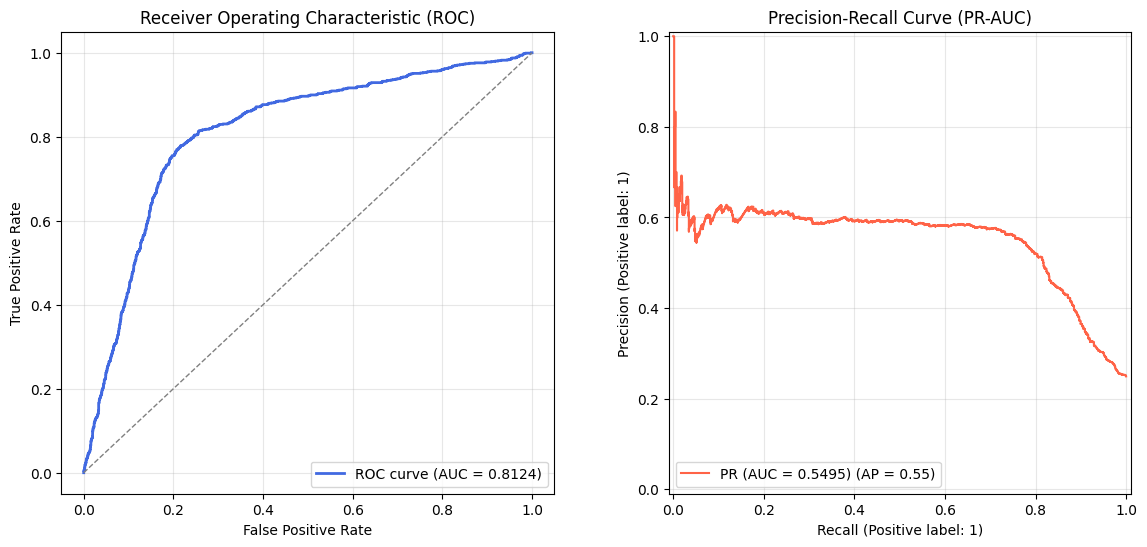

In [17]:
# Vẽ ROC-AUC và PR-AUC Curves
print("\n--- Biểu đồ ROC và PR ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
ax1.plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# PR Curve
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, ax=ax2, color='tomato', name=f'PR (AUC = {pr_auc:.4f})')
ax2.set_title('Precision-Recall Curve (PR-AUC)')
ax2.grid(alpha=0.3)
plt.show()


--- Feature Importance ---


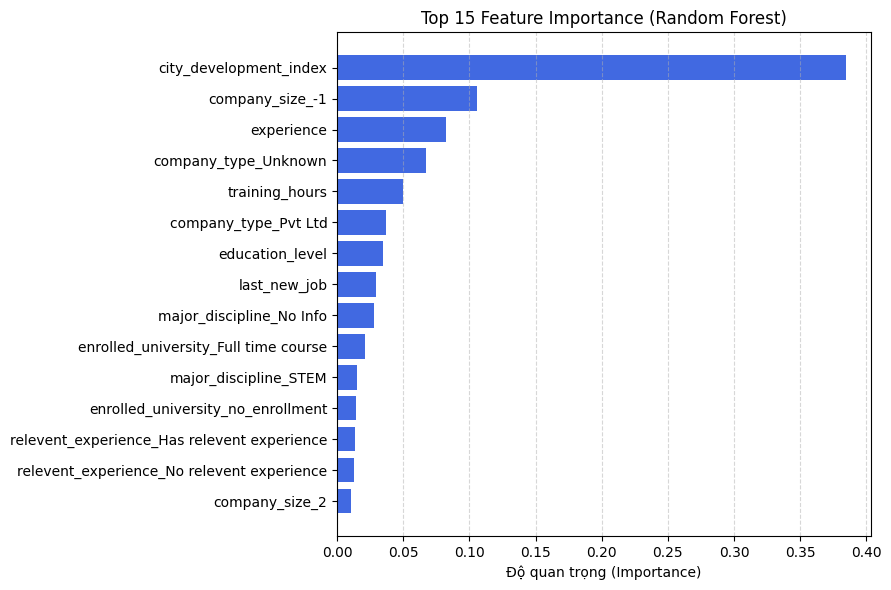

In [18]:
print("\n--- Feature Importance ---")

fitted_ct = best_rf_model.named_steps['col_transformer']
ohe_names = fitted_ct.named_transformers_['ohe'].get_feature_names_out(OHE_COLS_RF)
scaler_names = np.array(['city_development_index', FREQ_COL])
log_names = np.array(['training_hours'])
used_cols = list(OHE_COLS_RF) + ['city_development_index', FREQ_COL, 'training_hours']
remainder_names = np.array([c for c in X_train.columns if c not in used_cols])
feature_names = np.concatenate([ohe_names, scaler_names, log_names, remainder_names])
importances = best_rf_model.named_steps['model'].feature_importances_

feat_imp_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
top_n = 15
plot_df = feat_imp_df.head(top_n).sort_values('importance')
plt.figure(figsize=(9, 6))
plt.barh(plot_df['feature'], plot_df['importance'], color='royalblue')
plt.title(f'Top {top_n} Feature Importance (Random Forest)')
plt.xlabel('Độ quan trọng (Importance)')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
# Phân tích mẫu sai (Error Analysis)
print("\n--- Phân tích các mẫu dự đoán sai ---")
error_analysis_df = X_test.copy()
error_analysis_df['Thuc_te'] = y_test
error_analysis_df['Du_doan'] = y_test_pred_opt
error_analysis_df['Xac_suat'] = np.round(y_test_proba, 4)

# Lọc ra các mẫu dự đoán Sai (False Positives: Thực tế 0 - Đoán 1)
false_positives = error_analysis_df[(error_analysis_df['Thuc_te'] == 0) & (error_analysis_df['Du_doan'] == 1)]
print(f"Tổng số ca False Positive: {len(false_positives)}")
print("5 mẫu False Positive tiêu biểu:")
display(false_positives.head())


--- Phân tích các mẫu dự đoán sai ---
Tổng số ca False Positive: 620
5 mẫu False Positive tiêu biểu:


,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,Thuc_te,Du_doan,Xac_suat
14207,city_42,0.563,Female,No relevent experience,Full time course,Graduate,STEM,4,NaN,NaN,2,148,0,1,0.8148
32,city_103,0.920,Female,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,1,24,0,1,0.8234
16589,city_128,0.527,NaN,Has relevent experience,no_enrollment,Graduate,STEM,9,50-99,Pvt Ltd,4,16,0,1,0.6672
3564,city_103,0.920,NaN,Has relevent experience,no_enrollment,Masters,STEM,NaN,NaN,NaN,NaN,34,0,1,0.6510
12414,city_118,0.722,Male,No relevent experience,Full time course,Graduate,Humanities,6,NaN,NaN,2,162,0,1,0.6611


In [20]:
# Lưu mô hình tốt nhất
output_dir = 'rf_output'
os.makedirs(output_dir, exist_ok=True)

print("\n--- Lưu mô hình và Threshold ---")
print("="*50)
model_path = os.path.join(output_dir, 'best_randomforest_model.pkl')
joblib.dump(best_rf_model, model_path)
print(f"Đã lưu mô hình: {model_path}")
threshold_path = os.path.join(output_dir, 'best_threshold.txt')
with open(threshold_path, 'w') as f:
    f.write(str(optimal_threshold))
print(f"Đã lưu ngưỡng: {threshold_path} (Giá trị: {optimal_threshold:.4f})")

feature_path = os.path.join(output_dir, 'feature_names.txt')
with open(feature_path, 'w') as f:
    f.write(",".join(feature_names))
print(f"Danh sách đặc trưng: {feature_path}")

print("Đã lưu hoàn tất")


--- Lưu mô hình và Threshold ---
Đã lưu mô hình: rf_output\best_randomforest_model.pkl
Đã lưu ngưỡng: rf_output\best_threshold.txt (Giá trị: 0.5551)
Danh sách đặc trưng: rf_output\feature_names.txt
Đã lưu hoàn tất
